In [1]:
import pandas as pd
import numpy as np

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt

# Статистика
from scipy.stats import chisquare
import scipy.stats as stats

# Пользовательские функции
from utils.graphs import plot_funnel, compare_funnel_groups, daily_distribution_balance, hourly_distribution_balance
from utils.utils import analyze_group_period, analyze_metrics, calc_time_diff

## EDA

In [2]:
raw_data = pd.read_excel('Датасет.xlsx', header=1)

In [3]:
raw_data.head()

,id_order,test_group,time_order,time_offer,time_assign,time_arrive,trip_time
0,10001,0,04.3.2024 0:00:01,04.3.2024 0:00:42,04.3.2024 0:01:13,04.3.2024 0:09:07,04.3.2024 1:27:28
1,10002,0,04.3.2024 0:00:22,04.3.2024 0:01:00,04.3.2024 0:01:14,04.3.2024 0:08:45,04.3.2024 0:22:22
2,10003,1,04.3.2024 0:07:08,04.3.2024 0:07:44,NaN,NaN,NaN
3,10004,1,04.3.2024 0:07:11,04.3.2024 0:08:21,04.3.2024 0:08:46,04.3.2024 0:21:13,04.3.2024 1:23:25
4,10005,0,04.3.2024 0:11:59,04.3.2024 0:12:50,04.3.2024 0:13:09,04.3.2024 0:21:43,04.3.2024 0:46:45


In [4]:
raw_data.shape

(12281, 7)

In [5]:
raw_data.dtypes

id_order        int64
test_group      int64
time_order     object
time_offer     object
time_assign    object
time_arrive    object
trip_time      object
dtype: object

In [6]:
date_columns = ['time_order', 'time_offer', 'time_arrive', 'time_assign', 'trip_time']
for col in date_columns:
    raw_data[col] = pd.to_datetime(raw_data[col], format='%d.%m.%Y %H:%M:%S', errors='coerce')

In [7]:
raw_data.head()

,id_order,test_group,time_order,time_offer,time_assign,time_arrive,trip_time
0,10001,0,2024-03-04 00:00:01,2024-03-04 00:00:42,2024-03-04 00:01:13,2024-03-04 00:09:07,2024-03-04 01:27:28
1,10002,0,2024-03-04 00:00:22,2024-03-04 00:01:00,2024-03-04 00:01:14,2024-03-04 00:08:45,2024-03-04 00:22:22
2,10003,1,2024-03-04 00:07:08,2024-03-04 00:07:44,NaT,NaT,NaT
3,10004,1,2024-03-04 00:07:11,2024-03-04 00:08:21,2024-03-04 00:08:46,2024-03-04 00:21:13,2024-03-04 01:23:25
4,10005,0,2024-03-04 00:11:59,2024-03-04 00:12:50,2024-03-04 00:13:09,2024-03-04 00:21:43,2024-03-04 00:46:45


In [8]:
raw_data.duplicated().sum()

0

In [9]:
raw_data.nunique()

id_order       12281
test_group         2
time_order     11842
time_offer     10446
time_assign     9340
time_arrive     7561
trip_time       7245
dtype: int64

Все заказы уникальны и поделены на 2 группы

Оценим продолжительность и временные границы данных и сравним между группами

In [10]:
control_group = raw_data[raw_data['test_group'] == 0]
test_group = raw_data[raw_data['test_group'] == 1]
group_labels = ["Контрольная группа", "Тестовая группа"]

In [11]:
analyze_group_period(control_group, group_labels[0])

 Контрольная группа
 Начало периода: 2024-03-04 00:00:01
 Конец периода:  2024-03-10 23:33:23
 Общая продолжительность: 6 days 23:33:22


In [12]:
analyze_group_period(test_group, group_labels[1])

 Тестовая группа
 Начало периода: 2024-03-04 00:07:08
 Конец периода:  2024-03-10 23:45:48
 Общая продолжительность: 6 days 23:38:40


Границы групп по time_order и таймлапс в группах отличаются символически. Значит данные собирались в один промежуток времени. Это хорошо

In [13]:
raw_data.isna().sum()

id_order          0
test_group        0
time_order        0
time_offer     1500
time_assign    2657
time_arrive    4557
trip_time      4897
dtype: int64

Давайте пройдемся по столбцам по порядку:

1. **id_order**: 0

- Идентификаторы заказов присутствуют у всех записей. У нас есть полный список всех созданных заказов. 

2. **test_group**: 0

- Информация о тестовой группе заполнена для всех заказов. Это критически важно для любого анализа эффективности экспериментов. 

3. **time_order**: 0

- Время создания заказа указано для всех записей. Это основа для анализа временных меток.

4. **time_offer**: 1500

- Время получения предложения заказа водителю отсутствует в 1500 заказах. Это означает, что 1500 заказов не дошли до стадии предложения водителя. Возможные причины:

    - Заказ был отменен клиентом до поиска водителя.

    - В районе не было доступных водителей, и заказ "завис"
 
    - Проблемы с системой приоритизации водителя

    - Техническая ошибка при создании заказа

5. **time_assign**: 2657

- Время назначения водителя на заказ отсутствует в 2657 случаях. Это число включает в себя те 1500 заказов, где нет time_offer. *Ключевой момент*: 2657 - 1500 = 1157 заказов получили предложение (time_offer есть), но водитель так и не был назначен (time_assign нет). Это могло произойти, если клиент отменил заказ после получения предложения, но до окончательного назначения.

6. **time_arrive**: 4557

- Время прибытия водителя к точке посадки отсутствует в 4557 заказах. Это число включает в себя предыдущие 2657 заказов. Значит, 4557 - 2657 = 1900 заказов были назначены на водителя (time_assign есть), но водитель до них так и не доехал (или данные о прибытии не записались). Возможные причины:
    - водитель отменил заказ
    - клиент отменил заказ во время подачи машины
    - произошла техническая ошибка

7. **trip_time**: 4897

- Время поездки (или ее длительность) отсутствует в 4897 заказах.  Это финальная стадия. 4897 - 4557 = 340 заказов имеют время прибытия водителя (time_arrive есть), но не имеют времени поездки. Возможные причины:

    - Клиент отказался от поездки после того, как сел в машину

    - Произошел сбой в системе при начале поездки

    - Это короткие поездки, которые были некорректно обработаны

*Обработка пропусков в столбцах time_offer, time_assign, time_arrive, trip_time*:

Для анализа воронки заказов — это нормальные данные, пропуски показывают отсев. Их нельзя просто удалять или заполнять средним, так как они не случайны

Построим  и проанализируем график воронки заказов со следующими этапами:
1. *order2offer* - заказ предложен водителю
2. *offer2assign* - водитель назначен на заказ
3. *assign2arrive* - водитель прибыл к клиенту и поставил статус "ожидание"
4. *arrive2trip* - поездка завершена

In [14]:
len_raw_data = len(raw_data)

stages = [
    'orders',
    'order2offer',
    'order2assign',
    'order2arrive',
    'order2trip']

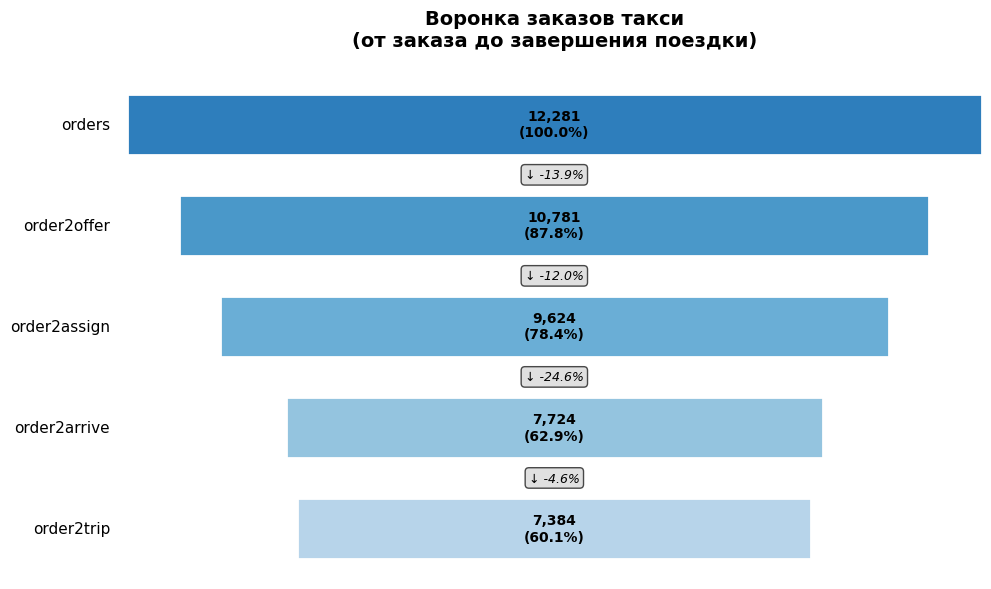

In [15]:
plot_funnel(raw_data, stages, len_raw_data)

**Ключевые инсайты**: 

- **Norhtstar - метрика (*order2trip*)**: 60.1% заказов доходит до завершения поездки

- Самая большая потеря (*assign2arrive*): 1900 заказов (24.6%) между назначением водителя и его прибытием к клиенту

- Лучшая конверсия (*arrive2trip*): 95% - если водитель прибыл к клиенту, поездка почти всегда завершается

- Первая значительная потеря (*order2offer*): 12% заказов не получают даже предложения по водителю

Теперь сравним воронки по группам

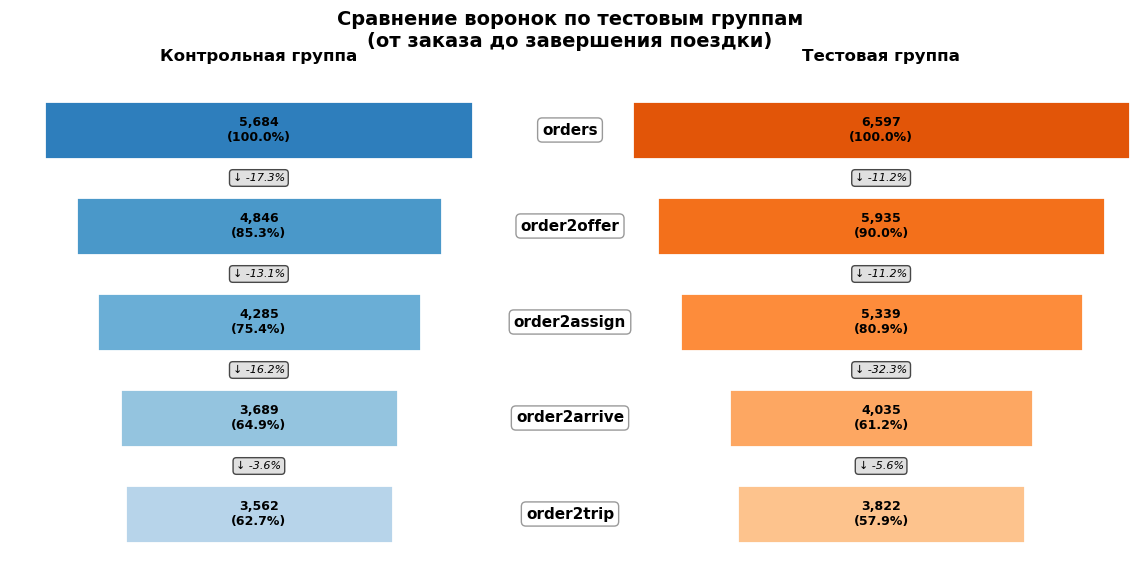

In [16]:
compare_funnel_groups(control_group, test_group, stages)

In [17]:
control_group_share = round((control_group.shape[0]/ raw_data.shape[0]) * 100, 2)
test_group_share = round((test_group.shape[0]/ raw_data.shape[0]) * 100, 2)
print(f'Всего заказов: {raw_data.shape[0]}')
print(f'Контрольная группа: {control_group.shape[0]} заказа')
print(f'Тестовая группа: {test_group.shape[0]} заказа')
print(f'Доля контрольной группы: {control_group_share}%')
print(f'Доля тестовой группы: {test_group_share}%')

Всего заказов: 12281
Контрольная группа: 5684 заказа
Тестовая группа: 6597 заказа
Доля контрольной группы: 46.28%
Доля тестовой группы: 53.72%


Проведем хи-квадрат тест на соответствие для проверки, равномерно ли распределены заказы между контрольной и тестовой группами.

In [18]:
observed = [control_group.shape[0], test_group.shape[0]]  
expected = [raw_data.shape[0]/2, raw_data.shape[0]/2]  

chi2, p_value = chisquare(observed, expected)
if p_value < 0.5:
    print('Отклоняем H₀ (распределение неравномерное)')
else:
    print('Нет оснований отклонять H₀ (распределение равномерное)')
print(chi2, p_value)

Отклоняем H₀ (распределение неравномерное)
67.87468447194854 1.7422374627455925e-16


    Исследуя данные, были выявлены следующие проблемы:
- Данные несбалансированы еще до применения целевого действия A/B-теста: различия на этапе order
- Неестественная форма просадки конверсии в тестовой группе: контроль 85% → 75% → 65% → 63% (плавное снижение), тест 90% → **81% → 61%** → 58% (резкий обрыв на этапе assign2arrive)
- Противоречивая динамика: тестовая группа лучше на ранних этапах, но значительно хуже на поздних. Это может указывать на разное качество трафика между группами
- Sample Ratio Missmatch: cплит-система не разбивает группы в отношении 50/50, как положено в задании (сейчас примерно 46/54)
    

Рассмотрим баланс распределений групп по дням и по часам

In [19]:
df = raw_data.copy()

In [20]:
# Проверка баланса распределения по дням
df['date'] = df['time_order'].dt.date
daily_split = df.groupby('date')['test_group'].value_counts(normalize=True).unstack()

<Figure size 1200x600 with 0 Axes>

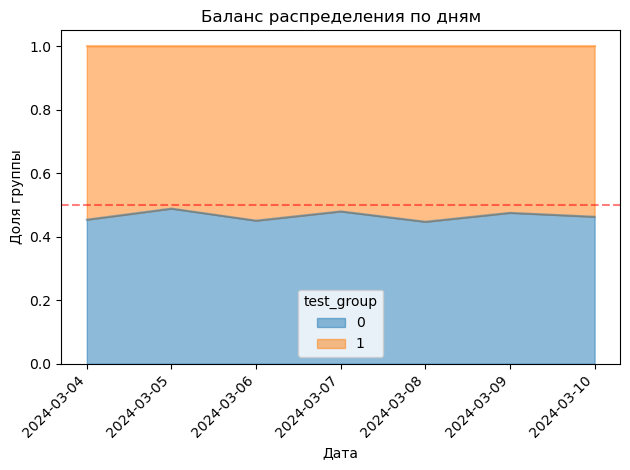

In [21]:
daily_distribution_balance(daily_split)

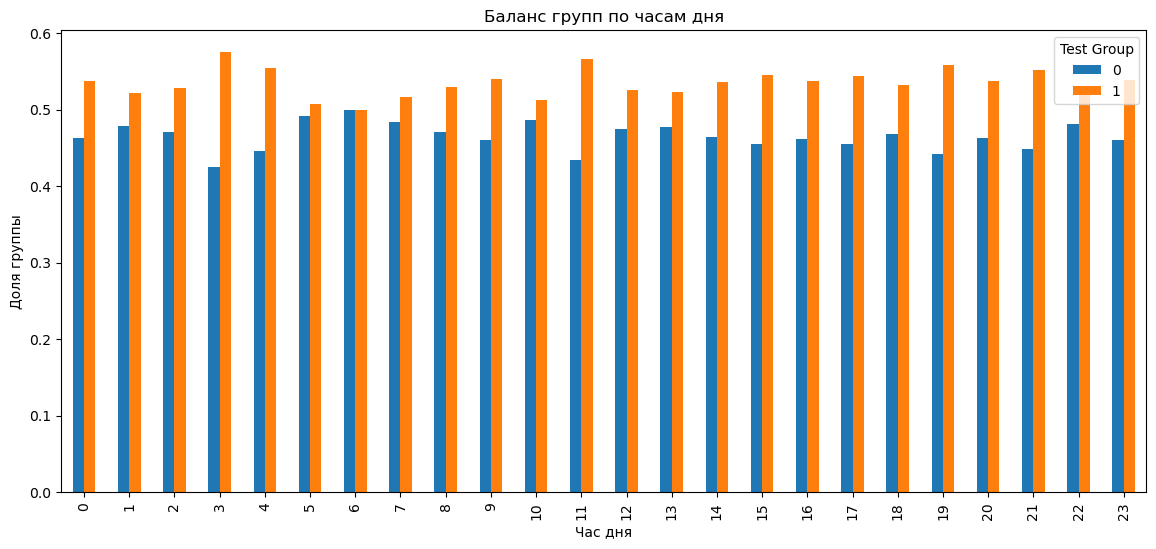

In [22]:
df['order_hour'] = df['time_order'].dt.hour
hourly_balance = pd.crosstab(df['order_hour'], df['test_group'], normalize='index')

hourly_distribution_balance(hourly_balance)

Судя по графикам наблюдается стабильный перекос при создании заказов в сторону тестовой группы

Рассчитаем временные метрики воронки и посмотрим на их графики и описательные статистики

In [23]:
df['order2offer_sec'] = df.apply(lambda x: calc_time_diff(x, 'time_order', 'time_offer'), axis=1)
df['offer2assign_sec'] = df.apply(lambda x: calc_time_diff(x, 'time_offer', 'time_assign'), axis=1)
df['assign2arrive_sec'] = df.apply(lambda x: calc_time_diff(x, 'time_assign', 'time_arrive'), axis=1)
df['arrive2trip_sec'] = df.apply(lambda x: calc_time_diff(x, 'time_arrive', 'trip_time'), axis=1)

# также создадим временную метрику для Northstar-метрики
df['order2trip_sec'] = df.apply(lambda x: calc_time_diff(x, 'time_order', 'trip_time'), axis=1)

In [24]:
df.head()

,id_order,test_group,time_order,time_offer,time_assign,time_arrive,trip_time,date,order_hour,order2offer_sec,offer2assign_sec,assign2arrive_sec,arrive2trip_sec,order2trip_sec
0,10001,0,2024-03-04 00:00:01,2024-03-04 00:00:42,2024-03-04 00:01:13,2024-03-04 00:09:07,2024-03-04 01:27:28,2024-03-04,0,41.0,31.0,474.0,4701.0,5247.0
1,10002,0,2024-03-04 00:00:22,2024-03-04 00:01:00,2024-03-04 00:01:14,2024-03-04 00:08:45,2024-03-04 00:22:22,2024-03-04,0,38.0,14.0,451.0,817.0,1320.0
2,10003,1,2024-03-04 00:07:08,2024-03-04 00:07:44,NaT,NaT,NaT,2024-03-04,0,36.0,NaN,NaN,NaN,NaN
3,10004,1,2024-03-04 00:07:11,2024-03-04 00:08:21,2024-03-04 00:08:46,2024-03-04 00:21:13,2024-03-04 01:23:25,2024-03-04,0,70.0,25.0,747.0,3732.0,4574.0
4,10005,0,2024-03-04 00:11:59,2024-03-04 00:12:50,2024-03-04 00:13:09,2024-03-04 00:21:43,2024-03-04 00:46:45,2024-03-04,0,51.0,19.0,514.0,1502.0,2086.0


In [25]:
df.groupby('test_group')[['order2offer_sec', 'offer2assign_sec', 'assign2arrive_sec', 'arrive2trip_sec']]\
    .agg({        
        'order2offer_sec':['mean', 'std'],
        'offer2assign_sec':['mean', 'std'],
        'assign2arrive_sec':['mean', 'std'],
        'arrive2trip_sec':['mean', 'std']
    })

order2offer_sec            offer2assign_sec                \
                      mean        std             mean           std   
test_group                                                             
0                68.297152  24.424497        28.527888      7.858160   
1                68.868745  24.168793     22626.914216  58680.995005   

           assign2arrive_sec             arrive2trip_sec               
                        mean         std            mean          std  
test_group                                                             
0                 405.217674  194.981900     3006.932061  3085.770494  
1                 539.607435  200.768226     2955.079540  1517.323297

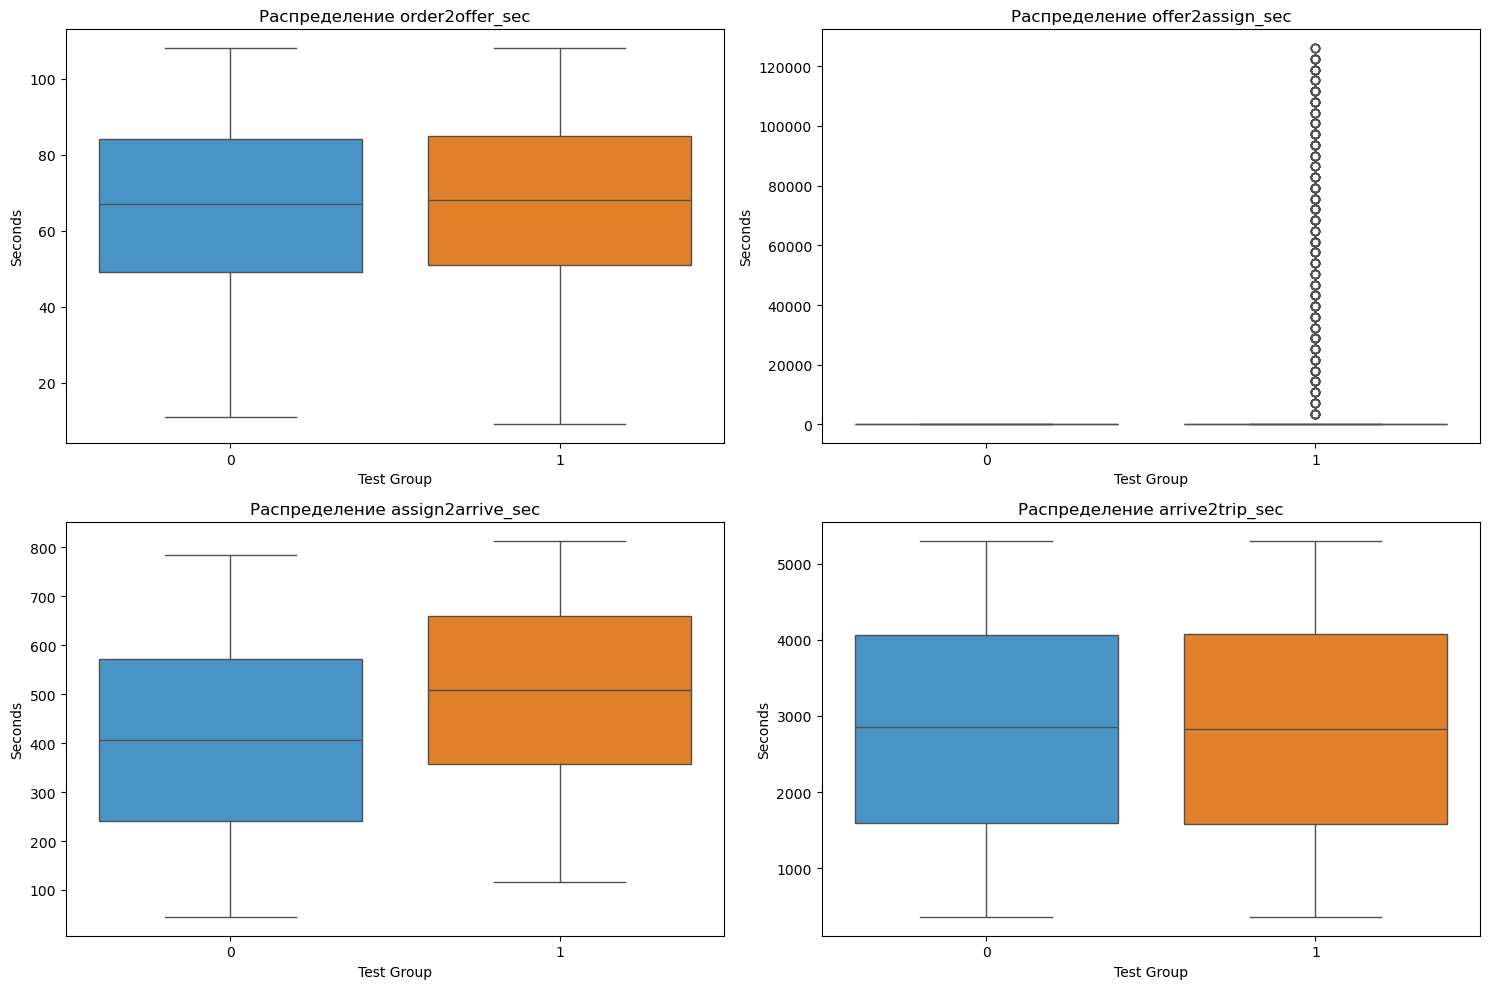

In [26]:
# Визуализация распределений
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

metrics = ['order2offer_sec', 'offer2assign_sec', 'assign2arrive_sec', 'arrive2trip_sec']

for i, metric in enumerate(metrics):
    data_to_plot = df[df[metric].notna() & (df[metric] <= df[metric].quantile(0.95))]
    sns.boxplot(data=data_to_plot, x='test_group', y=metric, hue='test_group', palette=['#3498db', '#ff7f0e'], legend=False, ax=axes[i])
    axes[i].set_title(f'Распределение {metric}')
    axes[i].set_xlabel('Test Group')
    axes[i].set_ylabel('Seconds')

plt.tight_layout()
plt.show()

Очевидно, что на этапе *offer2assign*  в тестовой группе появляются значительные выбросы, среднее значение и стандартное отклонение этапа также сильно отличаются между группами. Это препятствует проведению теста. 

Из задания нам известно, что в данных присутствуют отложенные заказы. Одной из причин этих выбросов могло быть то, что сплит-система отправляла все отложенные заказы (или их большую часть) в тестовую группу. Попробуем идентифицировать эти заказы и узнать о них побольше

## Отложенные заказы

In [27]:
df_control = df[df['test_group'] == 0]
df_test = df[df['test_group'] == 1]

In [28]:
df_control[['order2offer_sec', 'offer2assign_sec', 'assign2arrive_sec', 'arrive2trip_sec']].describe()

,order2offer_sec,offer2assign_sec,assign2arrive_sec,arrive2trip_sec
count,4846.000000,4285.000000,3689.000000,3562.000000
mean,68.297152,28.527888,405.217674,3006.932061
std,24.424497,7.858160,194.981900,3085.770494
min,11.000000,13.000000,45.000000,363.000000
25%,51.000000,22.000000,240.000000,1651.000000
50%,69.000000,29.000000,406.000000,2998.500000
75%,86.000000,35.000000,573.000000,4243.750000
max,129.000000,46.000000,785.000000,163902.000000


In [29]:
df_test[['order2offer_sec', 'offer2assign_sec', 'assign2arrive_sec', 'arrive2trip_sec']].describe()

,order2offer_sec,offer2assign_sec,assign2arrive_sec,arrive2trip_sec
count,5935.000000,5339.000000,4035.000000,3822.000000
mean,68.868745,22626.914216,539.607435,2955.079540
std,24.168793,58680.995005,200.768226,1517.323297
min,9.000000,13.000000,116.000000,361.000000
25%,51.000000,24.000000,371.000000,1648.250000
50%,70.000000,32.000000,541.000000,2970.000000
75%,87.000000,40.000000,708.000000,4282.000000
max,127.000000,259240.000000,963.000000,5580.000000


Максимально возможное время отклика водителя на заказ в *контрольной группе* равно 46 секундам. То есть водителю вполне хватает *минуты*, чтобы принять решение о принятии заказа. Буду считать это *максимальным временем отклика*. Посмотрим сколько водителей в *тестовой группе* откликаются на заказ позже этого времени

In [30]:
delayed = df_test.query('offer2assign_sec > 60').copy()

In [31]:
delayed[['offer2assign_sec']].describe()

,offer2assign_sec
count,920.000000
mean,131170.554348
std,75836.793012
min,3619.000000
25%,64832.750000
50%,129632.000000
75%,198023.500000
max,259240.000000


У нас набралось 920 заказов, в которых водитель принимает решение позже, чем через минуту. При этом минимальное время принятия заказа больше часа, а максимальное трое суток. Следовательно, эти заказы можно считать отложенными. Удалим их из тестовой выборки и снова сравним ее с контрольной.

In [32]:
df_control.shape[0], df_test.shape[0]

(5684, 6597)

In [33]:
df_test = df_test[~df_test['id_order'].isin(delayed['id_order'])].reset_index(drop=True)

In [34]:
df_control.shape[0], df_test.shape[0]

(5684, 5677)

In [35]:
df_control[['order2offer_sec', 'offer2assign_sec', 'assign2arrive_sec', 'arrive2trip_sec']].describe()

,order2offer_sec,offer2assign_sec,assign2arrive_sec,arrive2trip_sec
count,4846.000000,4285.000000,3689.000000,3562.000000
mean,68.297152,28.527888,405.217674,3006.932061
std,24.424497,7.858160,194.981900,3085.770494
min,11.000000,13.000000,45.000000,363.000000
25%,51.000000,22.000000,240.000000,1651.000000
50%,69.000000,29.000000,406.000000,2998.500000
75%,86.000000,35.000000,573.000000,4243.750000
max,129.000000,46.000000,785.000000,163902.000000


In [36]:
df_test[['order2offer_sec', 'offer2assign_sec', 'assign2arrive_sec', 'arrive2trip_sec']].describe()

,order2offer_sec,offer2assign_sec,assign2arrive_sec,arrive2trip_sec
count,5015.000000,4419.000000,3392.000000,3267.000000
mean,68.854636,29.007694,540.474351,2953.170799
std,24.220455,7.894301,201.879698,1515.727468
min,9.000000,13.000000,116.000000,361.000000
25%,51.000000,22.000000,371.000000,1654.000000
50%,70.000000,29.000000,543.000000,2966.000000
75%,87.000000,35.000000,709.250000,4277.500000
max,126.000000,46.000000,963.000000,5580.000000


In [37]:
df_len = df_control.shape[0] +  df_test.shape[0]
df_control_share = round((df_control.shape[0]/ df_len) * 100, 2)
df_test_share = round((df_test.shape[0]/ df_len) * 100, 2)
print(f'Всего заказов без учета отложенных: {df_len}')
print(f'Контрольная группа: {df_control.shape[0]} заказа')
print(f'Тестовая группа: {df_test.shape[0]} заказа')
print(f'Доля контрольной группы: {df_control_share}%')
print(f'Доля тестовой группы: {df_test_share}%')

Всего заказов без учета отложенных: 11361
Контрольная группа: 5684 заказа
Тестовая группа: 5677 заказа
Доля контрольной группы: 50.03%
Доля тестовой группы: 49.97%


In [38]:
observed = [df_control.shape[0], df_test.shape[0]]  
expected = [df_len/2, df_len/2]  

chi2, p_value = chisquare(observed, expected)
if p_value < 0.5:
    print('Отклоняем H₀ (распределение неравномерное)')
else:
    print('Нет оснований отклонять H₀ (распределение равномерное)')
print(chi2, p_value)

Нет оснований отклонять H₀ (распределение равномерное)
0.004313000616142945 0.9476378191977434


In [39]:
df = pd.concat([df_control, df_test], ignore_index=True).sort_values('id_order').reset_index(drop=True)

In [40]:
daily_split = df.groupby('date')['test_group'].value_counts(normalize=True).unstack()

<Figure size 1200x600 with 0 Axes>

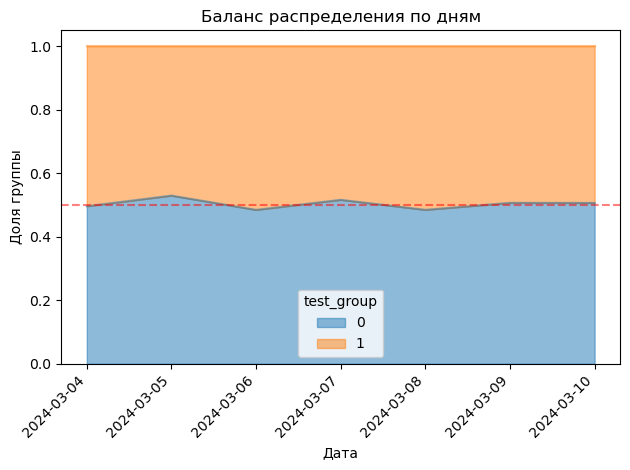

In [41]:
daily_distribution_balance(daily_split)

In [42]:
hourly_balance = pd.crosstab(df['order_hour'], df['test_group'], normalize='index')

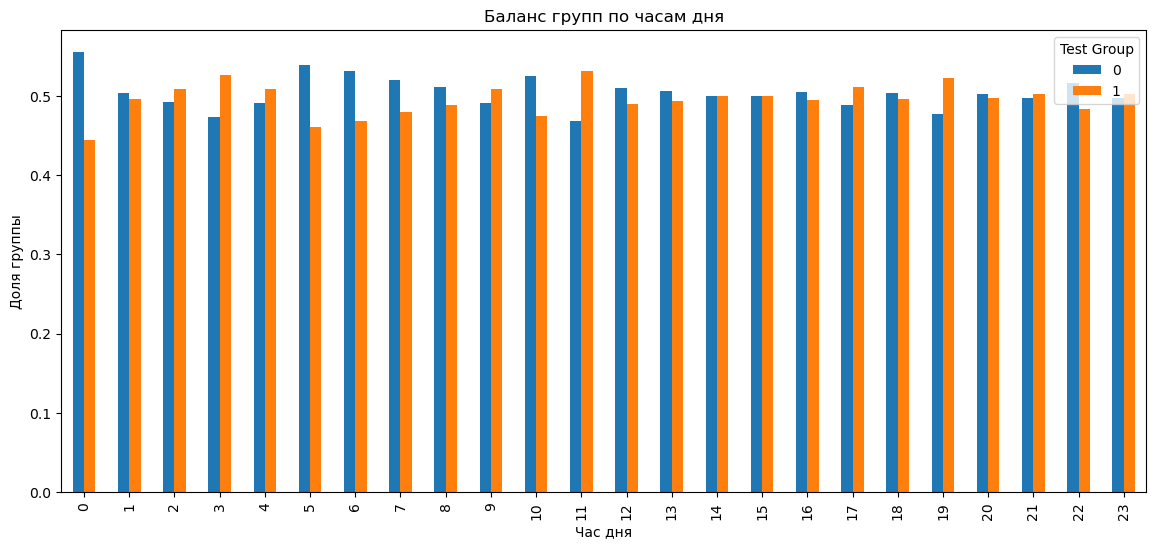

In [43]:
hourly_distribution_balance(hourly_balance)

#### Промежуточный вывод:

Все отложенные заказы отправлялись в тестовую группу. Это говорит о неправильной работе сплит-системы. После удаления отложенных заказов из тестовой группы (-7.5% от всех данных) нам удалось получить равномерное распределение данных по группам.

Посмотрим на  воронки по тестовым группам без отложенных заказов

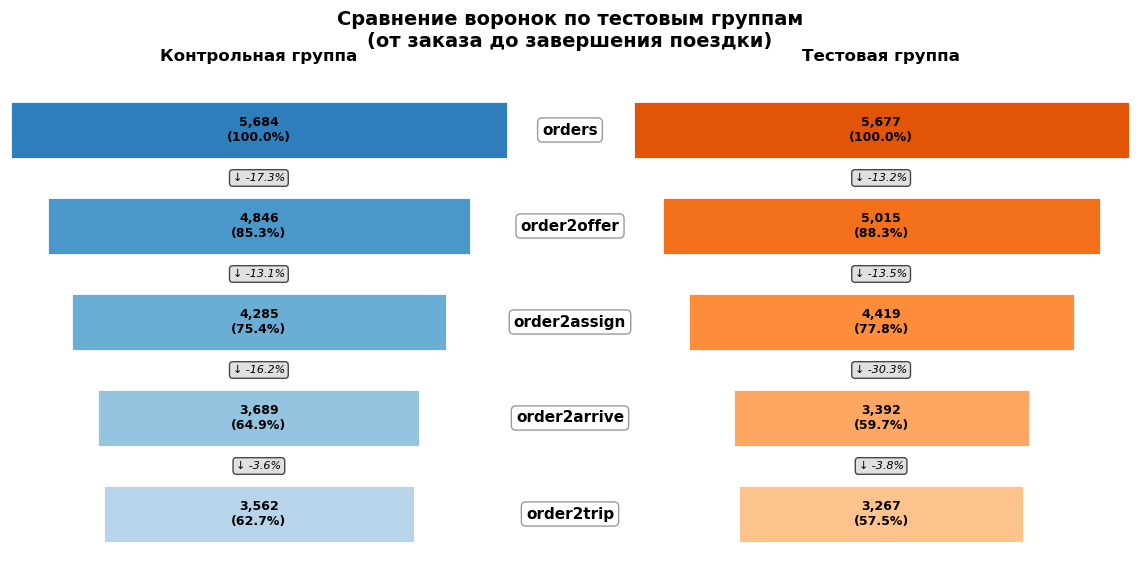

In [44]:
compare_funnel_groups(df_control, df_test, stages)

- Данные сбалансированы до применения целевого действия A/B-теста
- Падение **Norhtstar - метрики (*order2trip*)** в тестовой группе на 5%
- Противоречивая динамика в тестовой группе: несмотря на небольшое увеличение конверсии на ранних этапах (включая целевой этап *offer2assign*) мы видим огромную просадку на этапе *assign2arrive* (-30.3%). Налицо ухудшение пользовательского опыта

## AB-тест

У нас нет на руках полноценного дизайна AB-теста. Мы лишь имеем гипотезу: чем шире радиус, тем выше шанс найти водителя. Следовательно нас в первую интересует конверсия на этапе *offer2assign*. Но также мы не должны забывать про падение Northstar-метрики (*order2trip*) и конверсии *assign2arrive*. 

Создадим бинарные метрики интересующих нас этапов воронки

In [45]:
df['is_offer2assign'] = df['offer2assign_sec'].notna().astype(int)
df['is_assign2arrive'] = df['assign2arrive_sec'].notna().astype(int)
df['is_order2trip'] = df['order2trip_sec'].notna().astype(int)

In [46]:
df_control = df[df['test_group'] == 0].copy()
df_test = df[df['test_group'] == 1].copy()

In [47]:
# Сводная статистика по группам
offer2assign_summary = df.groupby('test_group').agg(
    n_offers=('id_order', 'count'),
    assign_rate=('is_offer2assign', 'mean'),
    time_mean=('offer2assign_sec', lambda x: x[x < x.quantile(0.95)].mean()),  # без выбросов
    time_median=('offer2assign_sec', 'median'),
    time_p90=('offer2assign_sec', lambda x: x.quantile(0.9)),
    time_std=('offer2assign_sec', lambda x: x[x < x.quantile(0.95)].std())
).round(3)

offer2assign_summary

,n_offers,assign_rate,time_mean,time_median,time_p90,time_std
test_group,,,,,,
0,5684,0.754,27.672,29.0,39.0,7.253
1,5677,0.778,28.053,29.0,40.0,7.256


In [48]:
# Сводная статистика по группам
assign2arrive_summary = df.groupby('test_group').agg(
    n_offers=('id_order', 'count'),
    arrive_rate=('is_assign2arrive', 'mean'),
    time_mean=('assign2arrive_sec', lambda x: x[x < x.quantile(0.95)].mean()),  # без выбросов
    time_median=('assign2arrive_sec', 'median'),
    time_p90=('assign2arrive_sec', lambda x: x.quantile(0.9)),
    time_std=('assign2arrive_sec', lambda x: x[x < x.quantile(0.95)].std())
).round(3)

assign2arrive_summary

,n_offers,arrive_rate,time_mean,time_median,time_p90,time_std
test_group,,,,,,
0,5684,0.649,387.081,406.0,672.0,183.860
1,5677,0.597,521.683,543.0,813.9,189.696


In [49]:
# Сводная статистика по группам
order2trip_summary = df.groupby('test_group').agg(
    n_offers=('id_order', 'count'),
    trip_rate=('is_order2trip', 'mean'),
    time_mean=('order2trip_sec', lambda x: x[x < x.quantile(0.95)].mean()),  # без выбросов
    time_median=('order2trip_sec', 'median'),
    time_p90=('order2trip_sec', lambda x: x.quantile(0.9)),
    time_std=('order2trip_sec', lambda x: x[x < x.quantile(0.95)].std())
).round(3)

order2trip_summary

,n_offers,trip_rate,time_mean,time_median,time_p90,time_std
test_group,,,,,,
0,5684,0.627,3326.474,3485.0,5521.0,1429.415
1,5677,0.575,3454.308,3624.0,5707.8,1449.948


In [50]:
# Запускаем анализ для offer2assign
analyze_metrics(df_control, df_test, 'is_offer2assign', alpha=0.05)

АНАЛИЗ ЭТАПА offer2assign
   Группа A: 0.7539 (4285/5684)
   Группа B: 0.7784 (4419/5677)
   Абсолютная разница: 0.0245
   Относительная разница: 3.25%
   Z-тест: p-value = 0.00201
   ✅ Статистически значимая разница в конверсии!


In [51]:
# Запускаем анализ assign2arrive
analyze_metrics(df_control, df_test, 'is_assign2arrive', alpha=0.05)

АНАЛИЗ ЭТАПА assign2arrive
   Группа A: 0.6490 (3689/5684)
   Группа B: 0.5975 (3392/5677)
   Абсолютная разница: -0.0515
   Относительная разница: -7.94%
   Z-тест: p-value = 0.00000
   ✅ Статистически значимая разница в конверсии!


In [52]:
# Запускаем анализ order2trip
analyze_metrics(df_control, df_test, 'is_order2trip', alpha=0.05)

АНАЛИЗ ЭТАПА order2trip
   Группа A: 0.6267 (3562/5684)
   Группа B: 0.5755 (3267/5677)
   Абсолютная разница: -0.0512
   Относительная разница: -8.17%
   Z-тест: p-value = 0.00000
   ✅ Статистически значимая разница в конверсии!


**Вывод**

Гипотеза частично подтвердилась, но с **критической** оговоркой: улучшение конверсии offer2assign привело к большему ухудшению assign2arrive. В итоге наша Northstar-метрика *order2trip* так же упала в тестовой группе 

## Рекомендации

- Отказаться от изменения расширения радиуса поиска — просадка конверсии *assign2arrive* перевешивает выгоду на *offer2assign*
- Переработать сплит-систему, чтобы она могла определять и распределять отложенные заказы случайным образом
- Провести качественное исследование (опросы, юзабилити-тесты) — почему пользователи тестовой группы отменяют заказы на этапе *assign2arrive*?
- Получить фидбек от водителей по поводу эксперимента
- Определять заказы с *offer2assign_sec* больше часа как отложенные заказы